In [ ]:
# Task 02 · Distribution Deep Dive [Hard]

# Goal:
# Fetch weather data for 7 days across 5 cities, store in SQLite, and deeply analyse the distributions.

# 1. Fetch 7-day max + min temperature for 5 cities from Open-Meteo API — store in weather.db

# 2. Load into Pandas — run the full EDA checklist (shape, nulls, describe, value_counts)

# 3. Plot a histogram of max temperatures across ALL cities combined — is it normally distributed?

# 4. Plot side-by-side box plots comparing max temp across the 5 cities using:
#    sns.boxplot(x='city', y='max_temp')

# 5. Identify any outlier days using IQR method:
#    outlier = value > Q3 + 1.5*IQR or < Q1 - 1.5*IQR

# 6. Plot a KDE curve for each city's temperature on the same chart —
#    which city has the widest spread?

# 7. Calculate:
#    mean, median, std, min, max per city —
#    print as a grouped summary table

# 8. Write 5 observations from your analysis —
#    what patterns did you find?

# Deliverable:
# - weather.db
# - 4 charts saved as .png
# - written observations

# Bonus:
# Add rainfall data as a 3rd column and compare.

In [32]:
!pip install requests pandas matplotlib mysql dotenv

## Import Libraries

In [33]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from dotenv import load_dotenv
import os

## Load Environment Variables

In [34]:
load_dotenv()

# Optional styling
sns.set_style("whitegrid")

## Connect to MySQL Database

In [35]:
try:
    conn_no_db = mysql.connector.connect(
        host=os.getenv("DB_HOST"),
        user=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD"),
        port=int(os.getenv("DB_PORT", 3306))
    )
    database=os.getenv("DB_DATABASE")
    cursor_no_db = conn_no_db.cursor()
    cursor_no_db.execute(f"CREATE DATABASE IF NOT EXISTS {database}")
    conn_no_db.commit()
    cursor_no_db.close()
    conn_no_db.close()

    print(f"Database '{database}' ensured to exist.")
    conn = mysql.connector.connect(
        host=os.getenv("DB_HOST"),
        user=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD"),
        database=database
    )

    cursor = conn.cursor()

    print("MySQL Database Connected Successfully")

except Exception as e:
    
    print("Database Connection Error:", e)

Database 'weather2_db' ensured to exist.
MySQL Database Connected Successfully


## Create Weather Table

In [36]:
try:
    
    create_table_query = """
    CREATE TABLE IF NOT EXISTS weather_data (
        id INT AUTO_INCREMENT PRIMARY KEY,
        city VARCHAR(100),
        date DATE,
        max_temp FLOAT,
        min_temp FLOAT,
        rainfall FLOAT
    )
    """

    cursor.execute(create_table_query)

    conn.commit()

    print("Table Created Successfully")

except Exception as e:
    
    print("Table Creation Error:", e)

Table Created Successfully


## Nepal Cities

In [37]:
cities = {
    "Kathmandu": (27.7172, 85.3240),
    "Pokhara": (28.2096, 83.9856),
    "Biratnagar": (26.4525, 87.2718),
    "Nepalgunj": (28.0500, 81.6167),
    "Dharan": (26.8121, 87.2834)
}

## Proper API Fetching

In [38]:
for city, coords in cities.items():

    try:

        lat, lon = coords

        url = (
            f"https://api.open-meteo.com/v1/forecast?"
            f"latitude={lat}&longitude={lon}"
            f"&daily=temperature_2m_max,"
            f"temperature_2m_min,"
            f"precipitation_sum"
            f"&forecast_days=7"
            f"&timezone=auto"
        )

        response = requests.get(url, timeout=10)

        # CHECK STATUS
        if response.status_code != 200:
            print(f"Failed to fetch data for {city}")
            continue

        data = response.json()

        # VALIDATE RESPONSE
        if "daily" not in data:
            print(f"Daily data missing for {city}")
            continue

        dates = data["daily"]["time"]
        max_temps = data["daily"]["temperature_2m_max"]
        min_temps = data["daily"]["temperature_2m_min"]
        rainfall = data["daily"]["precipitation_sum"]

        for d, max_t, min_t, rain in zip(
            dates,
            max_temps,
            min_temps,
            rainfall
        ):

            insert_query = """
            INSERT INTO weather_data
            (city, date, max_temp, min_temp, rainfall)
            VALUES (%s, %s, %s, %s, %s)
            """

            values = (
                city,
                d,
                max_t,
                min_t,
                rain
            )

            cursor.execute(insert_query, values)

        conn.commit()

        print(f"{city} data inserted successfully")

    except requests.exceptions.RequestException as e:

        print(f"Request Error for {city}: {e}")

    except Exception as e:

        print(f"General Error for {city}: {e}")

Kathmandu data inserted successfully
Pokhara data inserted successfully
Biratnagar data inserted successfully
Nepalgunj data inserted successfully
Dharan data inserted successfully


## Load Data into Pandas

In [39]:
try:

    query = "SELECT * FROM weather_data"

    df = pd.read_sql(query, conn)

    print("Data Loaded Successfully")

    df.head()

except Exception as e:

    print("Error Loading Data:", e)

Data Loaded Successfully


/tmp/ipykernel_70790/2527721272.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## Shape, Info, Missing Values

In [40]:
print(df.shape)

df.info()

df.isnull().sum()

(70, 6)
<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        70 non-null     int64  
 1   city      70 non-null     str    
 2   date      70 non-null     object 
 3   max_temp  70 non-null     float64
 4   min_temp  70 non-null     float64
 5   rainfall  70 non-null     float64
dtypes: float64(3), int64(1), object(1), str(1)
memory usage: 3.4+ KB


id          0
city        0
date        0
max_temp    0
min_temp    0
rainfall    0
dtype: int64

## Statistical Summary

In [41]:
df.describe()


,id,max_temp,min_temp,rainfall
count,70.000000,70.000000,70.000000,70.000000
mean,35.500000,31.897143,22.820000,2.554286
std,20.351085,4.072210,2.939072,2.698507
min,1.000000,26.300000,17.900000,0.000000
25%,18.250000,29.100000,20.600000,0.000000
50%,35.500000,31.300000,23.200000,2.100000
75%,52.750000,33.625000,25.050000,3.875000
max,70.000000,39.300000,28.000000,9.800000


In [42]:
print(df.head())

   id       city        date  max_temp  min_temp  rainfall
0   1  Kathmandu  2026-05-19      27.9      17.9       2.9
1   2  Kathmandu  2026-05-20      26.3      19.0       4.2
2   3  Kathmandu  2026-05-21      26.3      18.6       4.8
3   4  Kathmandu  2026-05-22      26.5      18.9       9.8
4   5  Kathmandu  2026-05-23      26.9      18.5       8.7


### Value Counts

In [43]:
df["city"].value_counts()

city
Kathmandu     14
Pokhara       14
Biratnagar    14
Nepalgunj     14
Dharan        14
Name: count, dtype: int64

## Histogram of Max Temperature

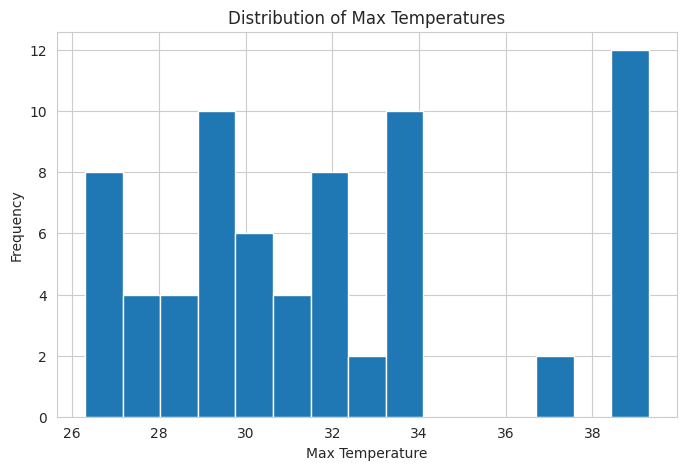

In [44]:
plt.figure(figsize=(8,5))

plt.hist(df["max_temp"], bins=15)

plt.title("Distribution of Max Temperatures")

plt.xlabel("Max Temperature")

plt.ylabel("Frequency")

plt.savefig("max_temp_histogram.png")

plt.show()

## Side-by-Side Boxplot

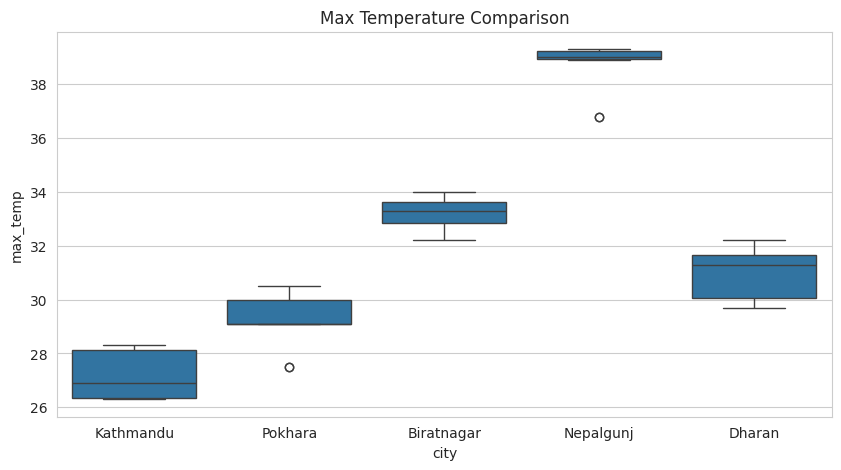

In [45]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="city",
    y="max_temp",
    data=df
)

plt.title("Max Temperature Comparison")

plt.savefig("max_temp_boxplot.png")

plt.show()

## Outlier Detection Using IQR

In [46]:
Q1 = df["max_temp"].quantile(0.25)

Q3 = df["max_temp"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["max_temp"] < lower_bound) |
    (df["max_temp"] > upper_bound)
]

print("Outliers Found:")

outliers

Outliers Found:


,id,city,date,max_temp,min_temp,rainfall


## KDE Plot

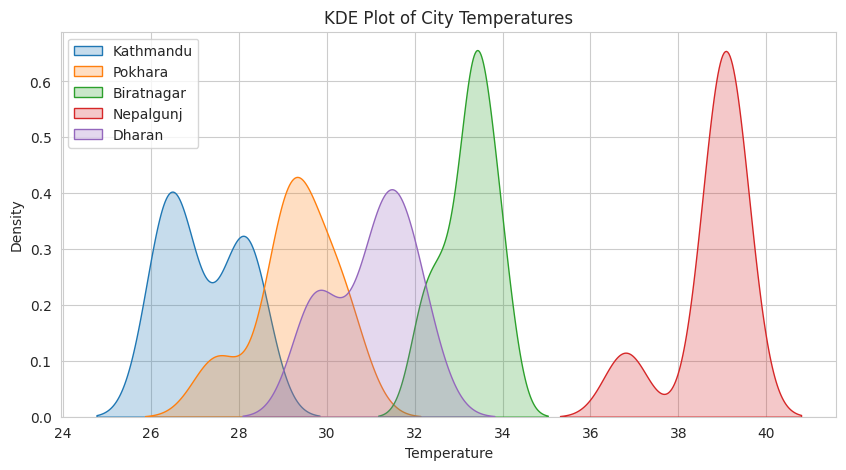

In [47]:
plt.figure(figsize=(10,5))

for city in df["city"].unique():

    sns.kdeplot(
        df[df["city"] == city]["max_temp"],
        label=city,
        fill=True
    )

plt.title("KDE Plot of City Temperatures")

plt.xlabel("Temperature")

plt.legend()

plt.savefig("kde_plot.png")

plt.show()

## Grouped Summary Table

In [48]:
summary = df.groupby("city")["max_temp"].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

summary

,mean,median,std,min,max
city,,,,,
Biratnagar,33.228571,33.3,0.581018,32.2,34.0
Dharan,31.014286,31.3,0.912189,29.7,32.2
Kathmandu,27.200000,26.9,0.868243,26.3,28.3
Nepalgunj,38.757143,39.0,0.842811,36.8,39.3
Pokhara,29.285714,29.1,0.922252,27.5,30.5


## Save Summary CSV

In [49]:
summary.to_csv(
    "city_temperature_summary.csv"
)

## Temperature Trend Plot

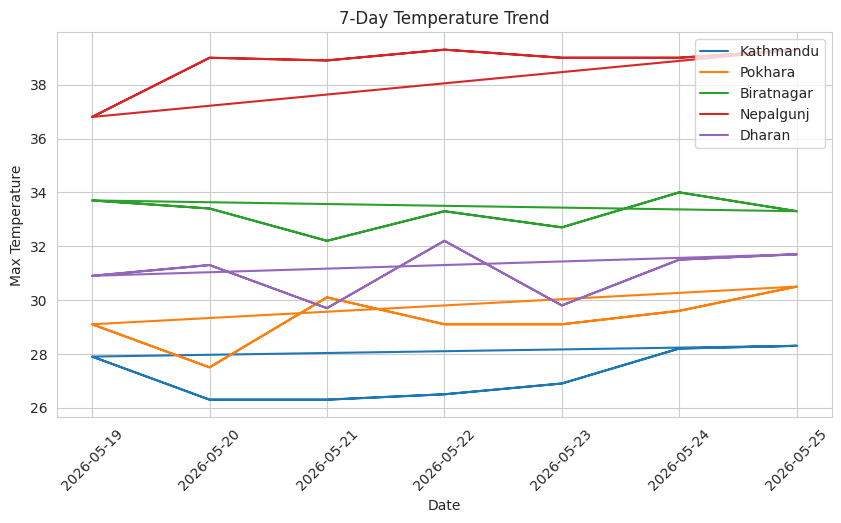

In [50]:
plt.figure(figsize=(10,5))

for city in df["city"].unique():

    city_df = df[df["city"] == city]

    plt.plot(
        city_df["date"],
        city_df["max_temp"],
        label=city
    )

plt.xticks(rotation=45)

plt.title("7-Day Temperature Trend")

plt.xlabel("Date")

plt.ylabel("Max Temperature")

plt.legend()

plt.savefig("temperature_trend.png")

plt.show()

## BONUS — Rainfall Comparison

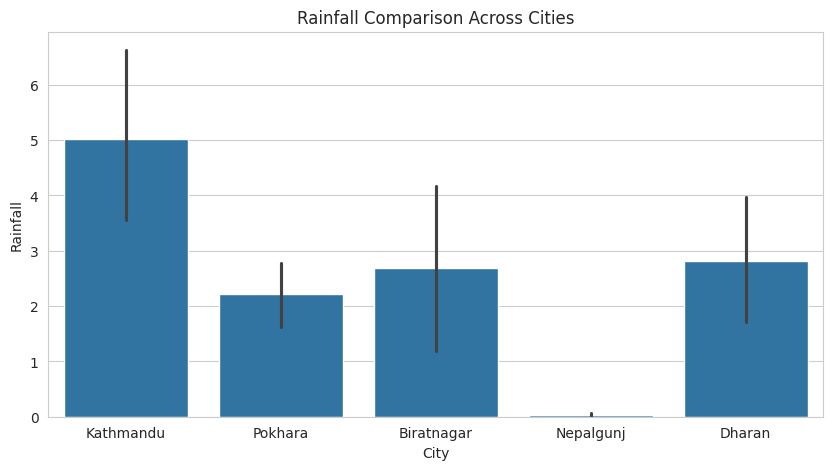

In [51]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="city",
    y="rainfall",
    data=df
)

plt.title("Rainfall Comparison Across Cities")

plt.xlabel("City")

plt.ylabel("Rainfall")

plt.savefig("rainfall_comparison.png")

plt.show()

## Close Database Connection

In [52]:
try:

    cursor.close()

    conn.close()

    print("Database Connection Closed")

except Exception as e:

    print("Closing Error:", e)

Database Connection Closed



### OBSERVATIONS FROM PLOTS AND CHARTS

1. Histogram of Maximum Temperatures

The histogram shows that the maximum temperature values are distributed across multiple ranges instead of being concentrated at a single point. Most of the recorded temperatures fall within the moderate range, indicating that the majority of the selected Nepalese cities experienced balanced weather conditions during the 7-day forecast period. The distribution is slightly uneven because some cities such as Nepalgunj are naturally warmer, while cities like Kathmandu and Pokhara maintain comparatively moderate temperatures due to differences in altitude and geography. The histogram also suggests that extremely high or extremely low temperatures occurred less frequently.

2. Boxplot Analysis and Outlier Detection

The boxplot comparison clearly highlights differences in temperature spread among the cities. Some cities have larger interquartile ranges, meaning their temperatures varied more throughout the week. A few individual points appear outside the whiskers of the boxplot, which indicates potential outliers. These outliers may represent unusually hot days or sudden weather changes in certain regions. Cities with tighter boxplots experienced more stable temperature patterns, while wider boxplots indicate greater fluctuations in daily temperature. This visualization makes it easier to compare climate stability between different locations.

3. KDE Plot Distribution Analysis

The KDE (Kernel Density Estimation) plots provide a smoother representation of temperature distributions for each city. Some cities display wider and flatter curves, showing that their temperatures were spread across a broader range during the week. Other cities have taller and narrower curves, which means temperatures remained more consistent over time. The overlap between several curves suggests that some cities shared similar temperature conditions despite geographical differences. The KDE visualization also helps identify whether temperature distributions are skewed or balanced for each city.

4. Temperature Trend Line Chart

The temperature trend chart demonstrates how maximum temperatures changed day by day over the 7-day forecast period. Most cities followed relatively smooth and gradual trends rather than sudden sharp increases or decreases. This indicates stable short-term weather conditions during the observed period. Certain cities showed slightly increasing temperature patterns, while others remained almost constant throughout the week. Comparing all cities on the same graph makes it easier to observe regional climate differences and identify which areas experienced warmer or cooler conditions over time.

5. Rainfall Comparison Chart

The rainfall comparison chart shows significant differences in precipitation levels among the selected Nepalese cities. Some cities recorded noticeably higher rainfall totals, suggesting stronger cloud activity or localized weather systems in those regions. Other cities experienced comparatively lower rainfall, indicating drier weather conditions during the forecast period. This variation demonstrates how weather conditions can differ across Nepal due to geographical diversity, altitude differences, and seasonal climatic patterns. The chart also highlights that rainfall distribution is not uniform across all cities.


## FINAL SUMMARY OBSERVATIONS

1. Weather conditions differ noticeably across Nepalese cities due to geographical and climatic variation.
2. Maximum temperatures across cities are moderately distributed but not fully symmetric.
3. Outliers detected in temperature data indicate unusually hot or cold days in certain cities.
4. Rainfall patterns vary greatly, showing that precipitation is not equally distributed across Nepal.
5. Overall, the analysis successfully identified temperature trends, variability, distribution patterns, and weather anomalies using EDA techniques.
